# Organização de arquivos e projetos

## Caminhos de arquivos

Quando estamos trabalhando em `python` ou outras linguagens de prorgamação e precisamos interagir com um arquivo precisamos que nosso código *encontre* o arquivo de interesse, para isso passamos o caminho (ou endereço) do arquivo. Para tanto, temos duas alternativas:
1. Caminho absoluto: que é fixo, e independente de em lugar estamos no nosso computador um mesmo arquivo tem sempre o mesmo caminho absoluto.
2. Caminho relativo: mutável, é expresso em relação ao caminho onde estamos.

Primeiro, o que queremos dizer com *onde estamos*? No caso de um notebook `python` ele roda em um lugar, e *enxerga* o computador em relação a esse lugar. Podemos descobrir qual é o caminho atual onde estamos dentro de um notebook pelos comandos
1. Em Windows: `cd` que sinigifica mudar de diretório (ou *change directory*, em inglês). Obs: esse comando serve para mudar para outra pasta, mas quando usamos ele sozinho ele retorna a pasta atual.
2. Em linux ou macOS: `!pwd`, em que `pwd` significa imrpima diretório atual (*print working directory*, em inglês).

In [52]:
!cd

c:\Users\Jo�o Lu�s\Desktop\eba-analista\python\aulas_python_II


**OBS**: O caminho acima é onde estão os notebooks no **meu** computador, caso você baixe os arquivos e tente rodar no seu computador poderá ter resultados diferentes, uma vez que pode ter salvo os arquivos em uma pasta diferente.

Sistemas operacionais diferentes tem padrões de barras diferentes:
- Windows: `C:\Workspace\EBA.PYTHON.II\data`
- Linux/macOS: `/home/usuario/documentos`

Apesar da diferença, dentro de programas como `python` é possível usar os dois sistemas, mas devemos estar atento a alguns problemas. 

Historicamente, a barra invertida (\) tem aplicação para comandos especiais (pular linha em uma string, símbolos etc). Em `python`, se queremos que uma string não interprete as barras invertidas como comandos usamos o prefixo r (de raw-string, ou string crua).

Para acessar o **caminho absoluto** de um arquivo podemos:
1. Usar uma ferramenta como o `VSCode` que permite selecionar o arquivo dentro do Workspace e clicando com o botão direito escolher a opção de copiar caminho:

![Captura de tela 2026-03-24 101933.png](<attachment:Captura de tela 2026-03-24 101933.png>)

2. Usando o navegador de arquivos, encontrar o caminho do arquivo:

![Captura de tela 2026-03-24 101939.png](<attachment:Captura de tela 2026-03-24 101939.png>)
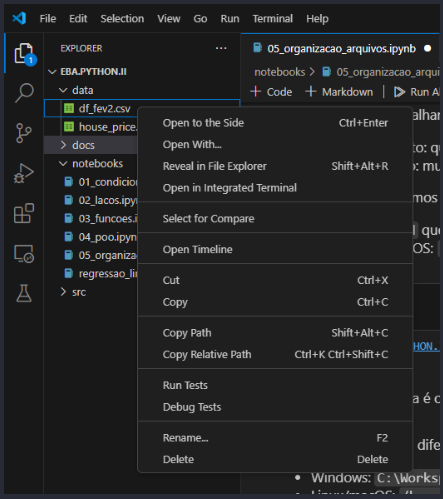
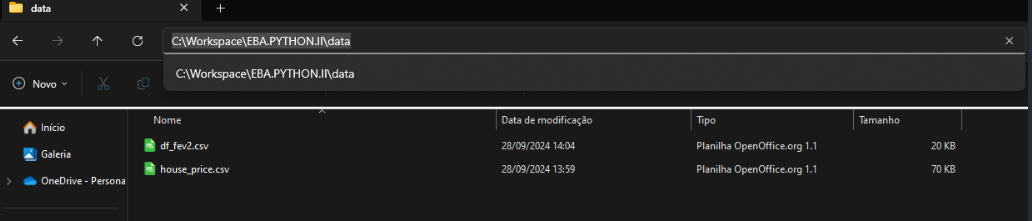

In [53]:
import pandas as pd

In [54]:
df = pd.read_csv(r"C:\Users\João Luís\Desktop\eba-analista\data\df_fev2.csv")
df.head()

,Unnamed: 0,age,fev,height,sex,smoke
0,0,9,1.953,68.0,masculino,sim
1,1,10,2.236,66.0,feminino,sim
2,3,13,2.216,68.0,feminino,sim
3,4,12,1.953,66.0,masculino,sim
4,5,10,2.198,62.0,feminino,sim


Podemos expressar o **caminho relativo** de um arquivo em relação a nossa pasta atual, para isso pensemos no arquivo `df_fev2.csv` que está na pasta `data`. Para acessá-lo partindo da pasta `c:\Workspace\EBA.PYTHON.II\notebooks` onde estamos precisamos: 
1. Subir um nível até `c:\Workspace\EBA.PYTHON.II`
2. Acessar `data`
3. Acessar `df_fev2.csv`

Para fazer isso podemos usar dois símbolos: `.` e `..`. Ponto (`.`) significa diterório atual. Enquanto dois pontos `..` sifnifica diretório *pai*, ou seja, a pasta imediatamente superior atual.

Por exemplo: em relação a pasta `c:\Workspace\EBA.PYTHON.II\notebooks` a pasta pai (`..`) é `c:\Workspace\EBA.PYTHON.II`.

Portanto, voltando ao exemplo inicial podemos escrever o caminho relativo do arquivo `df_fev2.csv` seguindo os passos:
1. Subir um nível `..` (que nos leva até `c:\Workspace\EBA.PYTHON.II`),
2. Acessar a pasta `data`,
3. Acessar `df_fev2.csv`.
Juntando as três partes (`..` + `data` + `df_fev2.csv` ) precisamos usar as barras: `../data/df_fev2.csv` ou `..\data\df_fev2.csv` no padrão Windows

## Organização de pastas

No contexo de projetos de dados é boa prática organizar nosso ambiente de tabalho por pastas, por exemplo nesse projeto os conteúdos estão divididos da seguinte forma:

1. `data` pasta para centralizar os arquivos de dados,
2. `docs` pasta para salvar documentos, 
3. `notebooks` pasta para colocar os notebooks que usamos,
4. `src` pasta para centralizar códigos (funções ou outros recursos).

Não há um critério fixo sobre como organizar os projetos, mas algumas boas práticas como separa códigos, documentos e dados são triviais. Em projetos mais complexos isso pode evoluir bastante. Por exemplo, é possível que entre os arquivos de dados existam arquivos brutos (que consumimos) e arquivos curados ou processados (que geramos em nossas análises). Portanto, poderíamos sub-dividir a pasta `data` em duas sub-pastas: `entrada` e `saida`.

Apesar de não haver nada fixo, há recursos que oferecem *templates* de projetos: https://www.cookiecutter.io/templates

## Acessando arquivos .py

Suponha que você tem alguns recuros que são usados em vários momentos, por exemplo uma função de cálculo de indicador ou uma conexão a base de dados. Esse é um caso em que gostaríamos de criar uma função para evitar repetir codigo. Porém, e se houvessem vários notebooks que usam a função? Inicialmente, as funções e recursos (variáveis) de um notebook não estão expostas para outro. Como acessar um mesmo recurso, como uma função nossa?

Temos algumas opções:

### A opção mais simples (e não elegante)

Seria criar um arquivo `.py` dentro da pasta dos nosso notebooks para acessarmos os códigos. Um exemplo seria o arquivo `exemplo_simples.py`. Usando o importo do python poderiamos acessar a função.

In [55]:
from exemplo_simples import funcao_exemplo_simples

In [56]:
funcao_exemplo_simples()

Essa é a função do exemolo simples


### Solução mais bonita

Alternativamente, ao invés de misturamos arquivos notebook e `.py` em um mesmo local seria legal colocarmos na pasta `notebooks` apenas os arquivos `.ipynb` e centralizarmos os arquivos `.py` em uma outra pasta, como `src`.

O problema é que ao fazermos isso, não conseguimos mais fazer o import direto como anteriormente. Isso porque o arquivo python não está na pasta do notebook. Para fazer o notebook *enxergar* a pasta `src` podemos usar:

In [57]:
import sys
sys.path.append("../src")

In [58]:
from exemplo_mais_bonito import funcao_exemplo_mais_bonito

In [59]:
funcao_exemplo_mais_bonito()

Exemplo Mais Bonito


Há outras opções, em particular poderíamos fazer nossa própria biblioteca com nossas funções de interesse. Porém, esse já é um tópico um pouco avançado e não muito relevante para os principais trabalhos que encontramos em análise de dados.

In [60]:
quantidades = [100, 200, 1000]
precos = [10, 15, 5]

In [61]:
total = 0

for q, p in zip(quantidades, precos):
    total = total + q*p

total

9000

In [62]:
sum([q*p for q, p in zip(quantidades,precos)])

9000

In [63]:
from total_vendas import calcular_total_vendas

In [64]:
calcular_total_vendas(quantidades, precos)

9000